In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

In [2]:
from online_shop_pipeline import fetch_data, save_data, clean_data

df = fetch_data()

## Ogólny schemat danych

Aby pracować z danymi, przyda się nam zarys tego, jak te dane wyglądają, co zawierają rekordy itp.

In [3]:
import pandas as pd

df = pd.concat([X,y], axis=1)
display(df.describe())
print(df.shape)


NameError: name 'X' is not defined

In [ ]:
display(df.describe(include=['object', 'bool', 'str']))
# 10 unique months - no january and april
print(df['Month'].value_counts())

,Month,VisitorType,Weekend,Revenue
count,12330,12330,12330,12330
unique,10,3,2,2
top,May,Returning_Visitor,False,False
freq,3364,10551,9462,10422


Month
May     3364
Nov     2998
Mar     1907
Dec     1727
Oct      549
Sep      448
Aug      433
Jul      432
June     288
Feb      184
Name: count, dtype: int64


In [ ]:
print(df.isnull().sum())

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [ ]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
df.tail(3)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12327,0,0.0,0,0.0,6,184.25,0.083333,0.086667,0.0,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.00,0.000000,0.021053,0.0,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.25,0.000000,0.066667,0.0,0.0,Nov,3,2,1,2,New_Visitor,True,False


## Wizualizacja danych

In [ ]:
try:
    import seaborn
except:
    !pip install matplotlib seaborn

<function matplotlib.pyplot.show(close=None, block=None)>

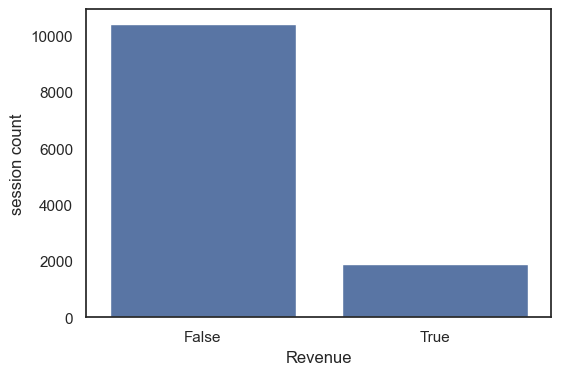

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")
# rozkład zmiennej docelowej revenue, która określa czy sesja zakończyła się zakupem
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Revenue')
plt.ylabel("session count")
plt.show

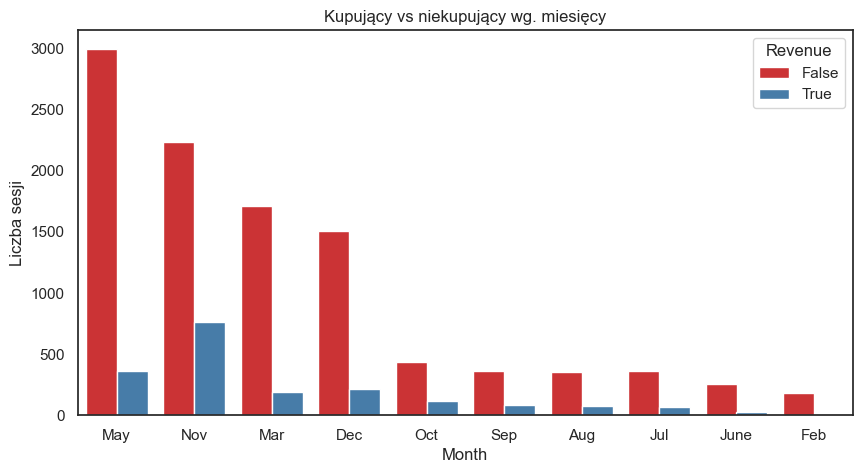

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Month', hue='Revenue', palette='Set1', 
              order=df['Month'].value_counts().index)
plt.title('Kupujący vs niekupujący wg. miesięcy')
plt.ylabel('Liczba sesji')
plt.show()

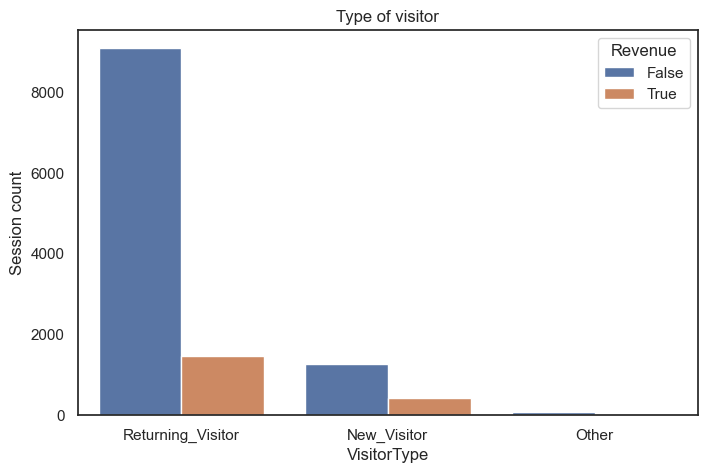

Returning: 0.1393232868922377
New: 0.24911452184179456
Overall proportion for every client: 0.15474452554744525


In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='VisitorType',hue='Revenue')
plt.title('Type of visitor')
plt.ylabel('Session count')
plt.show()

#proportions
returning_visitors = df[df['VisitorType'] == 'Returning_Visitor']
all_returning = len(returning_visitors)
true_returning = returning_visitors['Revenue'].sum()
returning_proportion = true_returning / all_returning

new_visitors = df[df['VisitorType'] == 'New_Visitor']
all_new = len(new_visitors)
true_new = new_visitors['Revenue'].sum()
new_proportion = true_new / all_new

print(f"Returning: {returning_proportion}")
print(f"New: {new_proportion}")

all_visitors = len(df)
true_all = df['Revenue'].sum()
all_proportion = true_all/all_visitors
print(f"Overall proportion for every client: {all_proportion}")


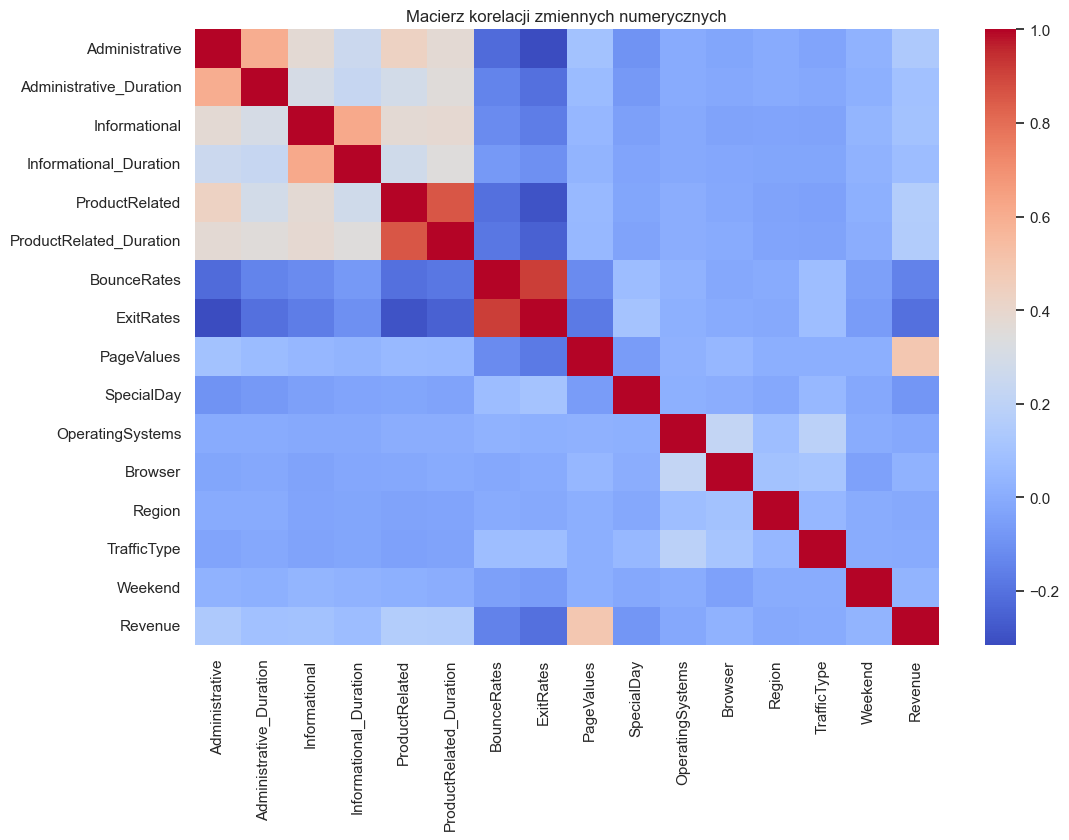

In [ ]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64', 'bool'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Macierz korelacji zmiennych numerycznych')
plt.show()

In [ ]:
#sprawdzenie ile sesji ma nierealistyczny czas przebywania na stronie
longest_visits = df.sort_values(by="ProductRelated_Duration", ascending=False)
print(longest_visits[['ProductRelated_Duration', 'Revenue']].head())

over_one_hour_count = (df['ProductRelated_Duration'] > 3600).sum()
print(f"Sesji powyżej godziny: {over_one_hour_count}")

over_hour = df[df['ProductRelated_Duration'] > 3600]
print("Zakupy w sesjach powyżej 1h:")
print(over_hour['Revenue'].value_counts())

      ProductRelated_Duration  Revenue
8071              63973.52223    False
5152              43171.23338    False
9238              29970.46597    False
8784              27009.85943     True
8308              24844.15620    False
Sesji powyżej godziny: 867
Zakupy w sesjach powyżej 1h:
Revenue
False    598
True     269
Name: count, dtype: int64


In [4]:
cleaned = clean_data(df)
save_data(cleaned,"../data/shop.csv")